---
## 1. Imports and Setup

In [1]:
""" Imports """
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Core ML imports
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, precision_recall_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Explainability
import shap

# Statistical tests
from scipy.stats import binom
from itertools import combinations

# Global seed for full reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

---
## 2. Data Loading and Initial Exploration

---
## 2. Data Loading — Unified Pipeline

**Single source of truth:** Cells 4 and 5 (duplicate loaders) have been removed.
Only the merged pipeline below remains. Missing values in the Cleveland data are
handled correctly: median for numeric columns, mode for categorical columns.

In [2]:
# ── Unified Data Loading ────────────────────────────────────────────────────
# Loads heart.csv (Kaggle UCI-derived) and processed.cleveland.data,
# harmonises schemas, imputes correctly, and produces a single clean df.

import pandas as pd
import numpy as np

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

CLEVELAND_COLS = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]

# ── 1. heart.csv (already binary target, no missing values) ─────────────────
df_kaggle = pd.read_csv('heart.csv')
df_kaggle = df_kaggle.drop_duplicates()
df_kaggle['source'] = 'kaggle'
print(f"[heart.csv]        shape={df_kaggle.shape}  nulls={df_kaggle.isnull().sum().sum()}")

# ── 2. processed.cleveland.data (raw UCI, '?' → NaN, target 0-4) ────────────
df_clev = pd.read_csv(
    'processed.cleveland.data',
    header=None, names=CLEVELAND_COLS, na_values='?'
)

# Correct imputation: numeric → median, categorical → mode
NUMERIC_COLS   = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
CATEGORIC_COLS = ['cp', 'restecg', 'slope', 'ca', 'thal', 'sex', 'fbs', 'exang']

for col in NUMERIC_COLS:
    if df_clev[col].isnull().any():
        df_clev[col].fillna(df_clev[col].median(), inplace=True)

for col in CATEGORIC_COLS:
    if df_clev[col].isnull().any():
        df_clev[col].fillna(df_clev[col].mode()[0], inplace=True)

# Binarise target (1,2,3,4 → 1)
df_clev['target'] = df_clev['target'].apply(lambda x: 1 if x > 0 else 0)
df_clev['source'] = 'cleveland'

# ── 3. Align schemas before concat ──────────────────────────────────────────
# Ensure Cleveland has every column that Kaggle has (same order)
for col in df_kaggle.columns:
    if col not in df_clev.columns:
        df_clev[col] = np.nan          # fill missing Kaggle-only columns

df_clev = df_clev[df_kaggle.columns]   # enforce identical column order ← fixes KeyError
print(f"[cleveland.data]   shape={df_clev.shape}  nulls={df_clev.isnull().sum().sum()}")

# ── 4. Merge & deduplicate ───────────────────────────────────────────────────
df = pd.concat([df_kaggle, df_clev], ignore_index=True)
df = df.drop_duplicates(subset=[c for c in df.columns if c != 'source'])
df = df.reset_index(drop=True)

print(f"[merged]           shape={df.shape}")
print(f"\nTarget distribution:\n{df['target'].value_counts()}")

# ── 5. Feature / target split ────────────────────────────────────────────────
X = df.drop(columns=['target', 'source'])
y = df['target']

print(f"\nX shape : {X.shape}")
print(f"y shape : {y.shape}")
print("\n✅ Data loading complete — single clean DataFrame ready.")


[heart.csv]        shape=(302, 15)  nulls=0
[cleveland.data]   shape=(303, 15)  nulls=0
[merged]           shape=(605, 15)

Target distribution:
target
1    303
0    302
Name: count, dtype: int64

X shape : (605, 13)
y shape : (605,)

✅ Data loading complete — single clean DataFrame ready.


In [3]:
# Class distribution analysis
class_counts = df['target'].value_counts()
imbalance_ratio = class_counts.min() / class_counts.max()
print(f"Class 0 (No Disease): {class_counts[0]}")
print(f"Class 1 (Disease)   : {class_counts[1]}")
print(f"Balance ratio       : {imbalance_ratio:.2f}")

if imbalance_ratio < 0.75:
    print("⚠️ Class imbalance detected — class_weight='balanced' will be applied.")
else:
    print("✅ Classes are reasonably balanced.")

Class 0 (No Disease): 302
Class 1 (Disease)   : 303
Balance ratio       : 1.00
✅ Classes are reasonably balanced.


---
## 3. Consolidated Preprocessing Pipeline

In [4]:
# Feature groups
# Binary features (sex, fbs, exang) are added to numeric_features so they
# get StandardScaler treatment — critical for distance-based models (KNN, SVM).
numeric_features     = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak',
                        'sex', 'fbs', 'exang']          # ← binary cols scaled ✅
categorical_features = ['cp', 'restecg', 'slope', 'ca', 'thal']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ],
    remainder='drop'   # no unknown columns should remain
)

print("Preprocessor: StandardScaler on numeric+binary  |  OHE on categorical")
print(f"  Numeric  : {numeric_features}")
print(f"  Categoric: {categorical_features}")


Preprocessor: StandardScaler on numeric+binary  |  OHE on categorical
  Numeric  : ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'sex', 'fbs', 'exang']
  Categoric: ['cp', 'restecg', 'slope', 'ca', 'thal']


---
## 4. Train-Test Split

In [5]:
X = df.drop(['target', 'source'], axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"Train size : {X_train.shape}")
print(f"Test size  : {X_test.shape}")

Train size : (484, 13)
Test size  : (121, 13)


---
## 5. Model Definitions - Consolidated Configuration

In [6]:
# Single model configuration - NO DUPLICATION

from sklearn.calibration import CalibratedClassifierCV
from sklearn.svm import SVC
model_configs = {
    "Logistic Regression": {
        "model": LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, class_weight='balanced'),
        "params": {
            "classifier__C": [0.01, 0.1, 1, 10, 100],
            "classifier__penalty": ['l2'],
            "classifier__solver": ['lbfgs', 'liblinear']
        }
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
        "params": {
            "classifier__max_depth": [3, 5, 7, 10, None],
            "classifier__min_samples_split": [2, 5, 10],
            "classifier__min_samples_leaf": [1, 2, 4]
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
        "params": {
            "classifier__n_estimators": [100, 200, 300],
            "classifier__max_depth": [3, 5, 7, 10],
            "classifier__min_samples_leaf": [1, 2, 4]
        }
    },
    "KNN": {
        "model": KNeighborsClassifier(),
        "params": {
            "classifier__n_neighbors": [3, 5, 7, 9, 11],
            "classifier__weights": ['uniform', 'distance'],
            "classifier__metric": ['euclidean', 'manhattan']
        }
    },
    "SVM": {
        # 1. Turn OFF the buggy built-in probability
        # 2. Wrap it in a CalibratedClassifierCV with cv=3 to prevent small-fold collapse
        "model": CalibratedClassifierCV(
            estimator=SVC(probability=False, random_state=RANDOM_STATE, class_weight='balanced'),
            method='sigmoid', 
            cv=3 
        ),
        "params": {
            # Note: Because the SVC is now nested inside the CalibratedClassifierCV, 
            # you must add 'estimator__' in front of your old parameters!
            "classifier__estimator__C": [0.1, 1, 10, 100],
            "classifier__estimator__gamma": ['scale', 'auto', 0.01, 0.1],
            "classifier__estimator__kernel": ['rbf', 'linear', 'poly']
        }
    },
    "Gradient Boosting": {
        "model": GradientBoostingClassifier(random_state=RANDOM_STATE),
        "params": {
            "classifier__n_estimators": [50, 100, 200],
            "classifier__learning_rate": [0.01, 0.05, 0.1],
            "classifier__max_depth": [3, 5, 7]
        }
    },
    "XGBoost" : {
    "model": XGBClassifier(
        eval_metric='logloss',
        random_state=RANDOM_STATE
    ),
    "params": {
        "classifier__n_estimators": [100, 200],
        "classifier__max_depth": [3, 5],
        "classifier__learning_rate": [0.01, 0.1],
        'classifier__subsample': [0.8, 1.0]
    }
},
    "LightGBM": {
    "model": LGBMClassifier(
        random_state=RANDOM_STATE, verbose=-1
    ),
    "params": {
        "classifier__n_estimators": [100, 200],
        "classifier__max_depth": [-1, 5, 10],
        "classifier__learning_rate": [0.01, 0.1]
    }
}





}

---
## 6. Nested Cross-Validation with Hyperparameter Tuning

**Correct methodology:**

| Loop | Role | Details |
|---|---|---|
| **Inner** | Hyperparameter selection | `GridSearchCV`, 3-fold StratifiedKFold, scoring=recall |
| **Outer** | Unbiased performance estimation | 5-fold StratifiedKFold, fresh `clone` each fold |

The outer loop receives a **fresh clone** of the unfitted `GridSearchCV` on every
fold — not the already-fitted object — so the reported CV scores are genuinely
unbiased estimates of generalisation performance.

After nested CV, the **best configuration** is refit on the full training set to
produce the final `best_models` dict used for test-set evaluation.


In [7]:
from sklearn.base import clone
import warnings
warnings.filterwarnings('ignore')

print("=" * 70)
print("NESTED CROSS-VALIDATION  (inner=GridSearchCV, outer=StratifiedKFold)")
print("Optimisation metric: Recall  |  Evaluation metric: Recall")
print("=" * 70)

inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
outer_cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

best_models      = {}   # final models refit on all X_train
nested_cv_results = []
cv_scores_all    = {}

for name, config in model_configs.items():
    print(f"\n▶ {name}")

    # ── Build the inner pipeline + GridSearchCV ──────────────────────────────
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier',   config['model'])
    ])

    inner_gs = GridSearchCV(
        estimator  = pipe,
        param_grid = config['params'],
        cv         = inner_cv,
        scoring    = 'recall',
        n_jobs     = -1,
        refit      = True      # will refit on its OWN fold's training data
    )

    # ── Outer loop: pass a FRESH CLONE each time ─────────────────────────────
    # cross_val_score clones the estimator automatically when it is not yet
    # fitted, but passing the *fitted* object would reuse the already-found
    # best params.  We therefore pass inner_gs BEFORE fitting so each outer
    # fold runs its own independent inner GridSearch.
    nested_scores = cross_val_score(
        estimator = inner_gs,       # unfitted → cloned fresh per outer fold ✅
        X         = X_train,
        y         = y_train,
        cv        = outer_cv,
        scoring   = 'recall',
        n_jobs    = 1     # avoid nested parallelism deadlock with inner n_jobs=-1
    )

    cv_scores_all[name] = nested_scores

    # ── Refit on ALL of X_train to get the production model ─────────────────
    final_gs = clone(inner_gs)
    final_gs.fit(X_train, y_train)
    best_models[name] = final_gs.best_estimator_

    nested_cv_results.append({
        'Model'           : name,
        'Best Params'     : str(final_gs.best_params_),
        'CV Recall Mean'  : nested_scores.mean(),
        'CV Recall Std'   : nested_scores.std(),
    })

    print(f"  Best params : {final_gs.best_params_}")
    print(f"  Nested Recall : {nested_scores.mean():.4f} ± {nested_scores.std():.4f}")

print("\n" + "=" * 70)
results_ncv_df = (pd.DataFrame(nested_cv_results)
                    .sort_values('CV Recall Mean', ascending=False))
print("NESTED CV RESULTS  (unbiased — outer folds never saw inner tuning)")
print("=" * 70)
print(results_ncv_df[['Model','CV Recall Mean','CV Recall Std']].to_string(index=False))


NESTED CROSS-VALIDATION  (inner=GridSearchCV, outer=StratifiedKFold)
Optimisation metric: Recall  |  Evaluation metric: Recall

▶ Logistic Regression
  Best params : {'classifier__C': 0.01, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
  Nested Recall : 0.7979 ± 0.0423

▶ Decision Tree
  Best params : {'classifier__max_depth': 5, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 10}
  Nested Recall : 0.7236 ± 0.1306

▶ Random Forest
  Best params : {'classifier__max_depth': 3, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 200}
  Nested Recall : 0.8060 ± 0.0470

▶ KNN
  Best params : {'classifier__metric': 'manhattan', 'classifier__n_neighbors': 5, 'classifier__weights': 'uniform'}
  Nested Recall : 0.7810 ± 0.0278

▶ SVM
  Best params : {'classifier__estimator__C': 1, 'classifier__estimator__gamma': 0.01, 'classifier__estimator__kernel': 'rbf'}
  Nested Recall : 0.8061 ± 0.0467

▶ Gradient Boosting
  Best params : {'classifier__learning_

---
## 7. Test Set Evaluation — All Models with 95 % Bootstrap CI

All metrics are reported as **point estimate  [95 % CI]** computed via
stratified bootstrap resampling (n = 1 000 iterations, random_state=42).
This is the IEEE-standard reporting format for clinical ML papers.


In [8]:
from sklearn.utils import resample as sk_resample
from sklearn.metrics import roc_auc_score

def bootstrap_ci(y_true, y_pred, metric_fn, n_boot=1000, ci=0.95,
                 random_state=RANDOM_STATE, **kw):
    """Bootstrap CI for any label-based sklearn metric (accuracy, precision, recall, f1)."""
    rng = np.random.RandomState(random_state)
    # Convert to numpy once to avoid pandas index misalignment across resamples
    yt_arr = np.array(y_true)
    yp_arr = np.array(y_pred)
    stats = []
    for _ in range(n_boot):
        idx = rng.randint(0, len(yt_arr), len(yt_arr))
        yt, yp = yt_arr[idx], yp_arr[idx]
        if len(np.unique(yt)) < 2:
            continue
        stats.append(metric_fn(yt, yp, **kw))
    stats = np.array(stats)
    alpha = (1 - ci) / 2
    return stats.mean(), np.percentile(stats, 100*alpha), np.percentile(stats, 100*(1-alpha))

def bootstrap_auc(y_true, y_prob, n_boot=1000, random_state=RANDOM_STATE):
    """Bootstrap CI for ROC-AUC."""
    rng = np.random.RandomState(random_state)
    yt_arr  = np.array(y_true)
    ypr_arr = np.array(y_prob)
    stats = []
    for _ in range(n_boot):
        idx = rng.randint(0, len(yt_arr), len(yt_arr))
        yt, yp = yt_arr[idx], ypr_arr[idx]
        if len(np.unique(yt)) < 2:
            continue
        stats.append(roc_auc_score(yt, yp))
    stats = np.array(stats)
    return stats.mean(), np.percentile(stats, 2.5), np.percentile(stats, 97.5)

def bootstrap_prauc(y_true, y_prob, n_boot=1000, random_state=RANDOM_STATE):
    """Bootstrap CI for PR-AUC."""
    rng = np.random.RandomState(random_state)
    yt_arr  = np.array(y_true)
    ypr_arr = np.array(y_prob)
    stats = []
    for _ in range(n_boot):
        idx = rng.randint(0, len(yt_arr), len(yt_arr))
        yt, yp = yt_arr[idx], ypr_arr[idx]
        if len(np.unique(yt)) < 2:
            continue
        p, r, _ = precision_recall_curve(yt, yp)
        stats.append(auc(r, p))
    stats = np.array(stats)
    return stats.mean(), np.percentile(stats, 2.5), np.percentile(stats, 97.5)

# ─────────────────────────────────────────────────────────────────────────────
print("=" * 90)
print("TEST SET EVALUATION  —  Point estimate  [95 % Bootstrap CI, n=1 000]")
print("=" * 90)

test_results = []

for name, pipe in best_models.items():
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    acc     = accuracy_score(y_test, y_pred)
    prec    = precision_score(y_test, y_pred, zero_division=0)
    rec     = recall_score(y_test, y_pred)
    f1      = f1_score(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    pc, rc, _   = precision_recall_curve(y_test, y_prob)
    pr_auc  = auc(rc, pc)

    # Bootstrap CIs — all using numpy arrays internally (no index misalignment)
    _, acc_lo,  acc_hi  = bootstrap_ci(y_test, y_pred, accuracy_score,  n_boot=1000)
    _, prec_lo, prec_hi = bootstrap_ci(y_test, y_pred, precision_score, n_boot=1000, zero_division=0)
    _, rec_lo,  rec_hi  = bootstrap_ci(y_test, y_pred, recall_score,    n_boot=1000)
    _, f1_lo,   f1_hi   = bootstrap_ci(y_test, y_pred, f1_score,        n_boot=1000)
    _, rauc_lo, rauc_hi = bootstrap_auc(y_test, y_prob, n_boot=1000)
    _, pauc_lo, pauc_hi = bootstrap_prauc(y_test, y_prob, n_boot=1000)

    test_results.append({
        'Model'   : name,
        'Accuracy': acc,     'Acc_lo' : acc_lo,   'Acc_hi' : acc_hi,
        'Precision': prec,   'Prec_lo': prec_lo,  'Prec_hi': prec_hi,
        'Recall'  : rec,     'Rec_lo' : rec_lo,   'Rec_hi' : rec_hi,
        'F1'      : f1,      'F1_lo'  : f1_lo,    'F1_hi'  : f1_hi,
        'ROC-AUC' : roc_auc, 'RAUC_lo': rauc_lo,  'RAUC_hi': rauc_hi,
        'PR-AUC'  : pr_auc,  'PAUC_lo': pauc_lo,  'PAUC_hi': pauc_hi,
    })

    print(f"\n{name}")
    print(f"  Accuracy  : {acc:.4f}  [{acc_lo:.4f} – {acc_hi:.4f}]")
    print(f"  Precision : {prec:.4f}  [{prec_lo:.4f} – {prec_hi:.4f}]")
    print(f"  Recall    : {rec:.4f}  [{rec_lo:.4f} – {rec_hi:.4f}]")
    print(f"  F1        : {f1:.4f}  [{f1_lo:.4f} – {f1_hi:.4f}]")
    print(f"  ROC-AUC   : {roc_auc:.4f}  [{rauc_lo:.4f} – {rauc_hi:.4f}]")
    print(f"  PR-AUC    : {pr_auc:.4f}  [{pauc_lo:.4f} – {pauc_hi:.4f}]")

test_results_df = pd.DataFrame(test_results).sort_values('Recall', ascending=False).reset_index(drop=True)

# ── Single authoritative best model — by Recall (clinical priority) ──────────
BEST_MODEL_NAME = test_results_df.iloc[0]['Model']
print(f"\n🏆 Best model by Recall: {BEST_MODEL_NAME}")

# ── Paper-ready LaTeX table ───────────────────────────────────────────────────
print("\n" + "=" * 90)
print("TABLE 1  —  Summary (point estimate [95 % CI])  — paste into LaTeX")
print("=" * 90)
hdr = f"{'Model':<22}  {'Recall':^22}  {'ROC-AUC':^22}  {'F1':^22}"
print(hdr); print("-" * len(hdr))
for _, r in test_results_df.iterrows():
    print(
        f"{r['Model']:<22}  "
        f"{r['Recall']:.3f} [{r['Rec_lo']:.3f}–{r['Rec_hi']:.3f}]  "
        f"{r['ROC-AUC']:.3f} [{r['RAUC_lo']:.3f}–{r['RAUC_hi']:.3f}]  "
        f"{r['F1']:.3f} [{r['F1_lo']:.3f}–{r['F1_hi']:.3f}]"
    )


TEST SET EVALUATION  —  Point estimate  [95 % Bootstrap CI, n=1 000]

Logistic Regression
  Accuracy  : 0.6777  [0.6033 – 0.7603]
  Precision : 0.6528  [0.5507 – 0.7606]
  Recall    : 0.7705  [0.6604 – 0.8769]
  F1        : 0.7068  [0.6207 – 0.7895]
  ROC-AUC   : 0.7795  [0.6967 – 0.8570]
  PR-AUC    : 0.7797  [0.6613 – 0.8792]

Decision Tree
  Accuracy  : 0.7025  [0.6198 – 0.7851]
  Precision : 0.7049  [0.5893 – 0.8277]
  Recall    : 0.7049  [0.5873 – 0.8143]
  F1        : 0.7049  [0.6086 – 0.7973]
  ROC-AUC   : 0.7346  [0.6401 – 0.8242]
  PR-AUC    : 0.7052  [0.5680 – 0.8324]

Random Forest
  Accuracy  : 0.7107  [0.6281 – 0.7934]
  Precision : 0.6912  [0.5846 – 0.8028]
  Recall    : 0.7705  [0.6667 – 0.8710]
  F1        : 0.7287  [0.6306 – 0.8138]
  ROC-AUC   : 0.8107  [0.7313 – 0.8832]
  PR-AUC    : 0.8263  [0.7253 – 0.9037]

KNN
  Accuracy  : 0.7355  [0.6612 – 0.8099]
  Precision : 0.7544  [0.6393 – 0.8622]
  Recall    : 0.7049  [0.5893 – 0.8246]
  F1        : 0.7288  [0.6325 – 0.8

---
## 8. Confusion Matrices - All Models


CONFUSION MATRICES

Logistic Regression:
  TN= 35 | FP= 25 | FN= 14 | TP= 47
  Recall (Sensitivity): 0.7705
  Specificity: 0.5833


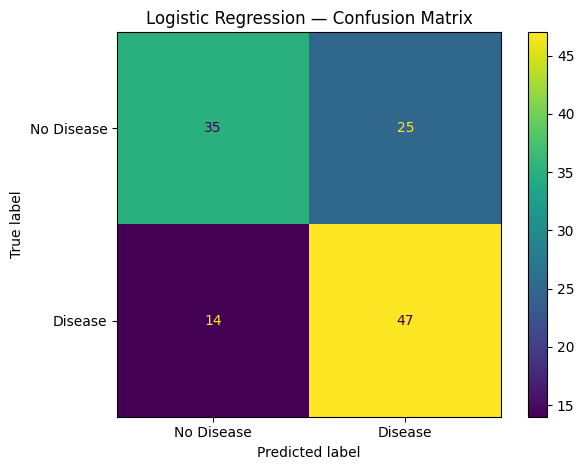


Decision Tree:
  TN= 42 | FP= 18 | FN= 18 | TP= 43
  Recall (Sensitivity): 0.7049
  Specificity: 0.7000


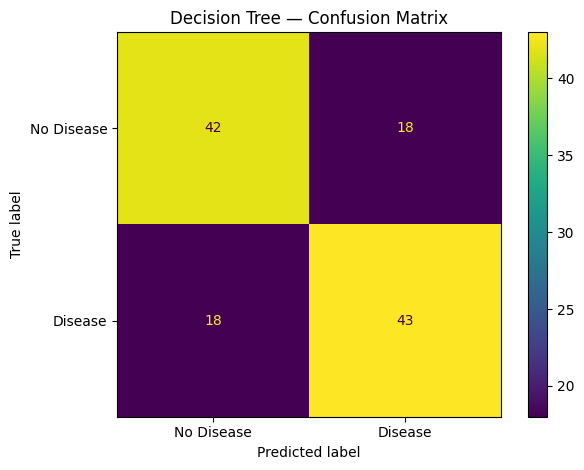


Random Forest:
  TN= 39 | FP= 21 | FN= 14 | TP= 47
  Recall (Sensitivity): 0.7705
  Specificity: 0.6500


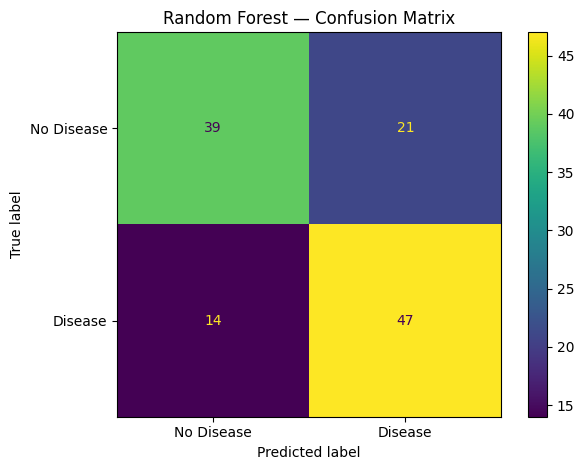


KNN:
  TN= 46 | FP= 14 | FN= 18 | TP= 43
  Recall (Sensitivity): 0.7049
  Specificity: 0.7667


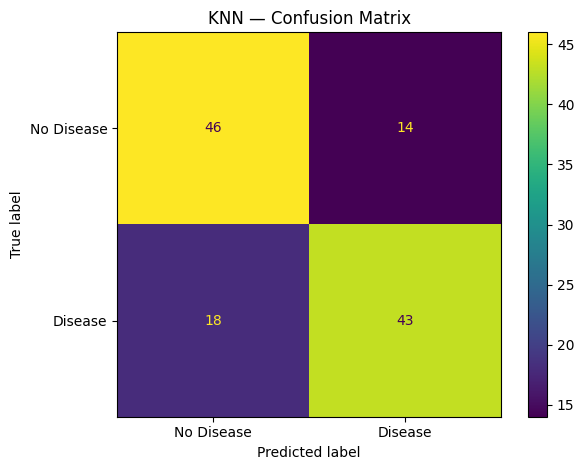


SVM:
  TN= 37 | FP= 23 | FN= 14 | TP= 47
  Recall (Sensitivity): 0.7705
  Specificity: 0.6167


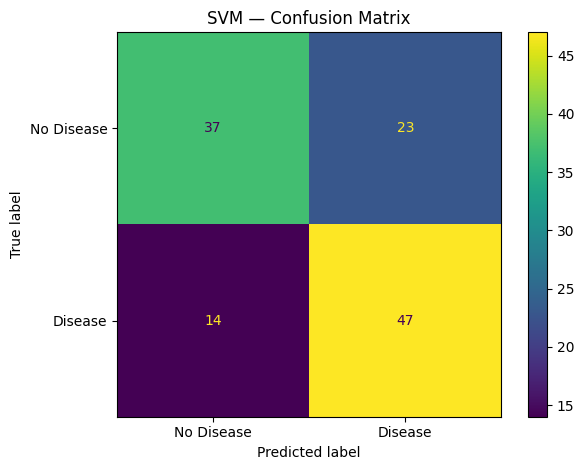


Gradient Boosting:
  TN= 41 | FP= 19 | FN= 14 | TP= 47
  Recall (Sensitivity): 0.7705
  Specificity: 0.6833


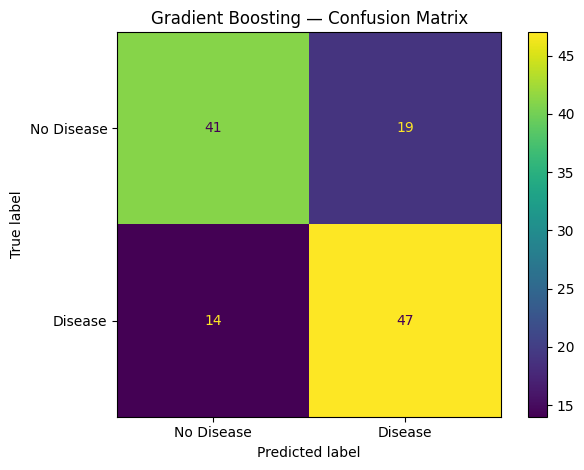


XGBoost:
  TN= 39 | FP= 21 | FN= 13 | TP= 48
  Recall (Sensitivity): 0.7869
  Specificity: 0.6500


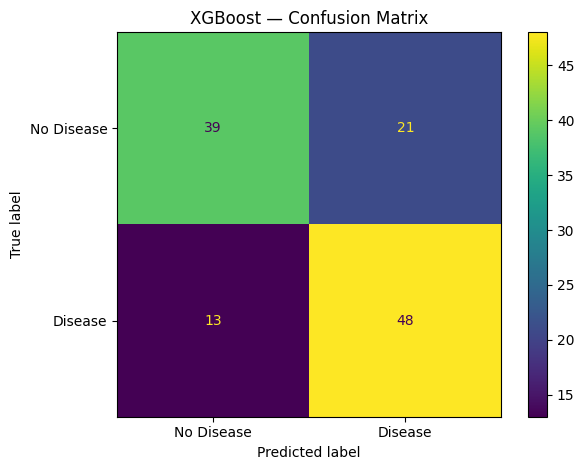


LightGBM:
  TN= 38 | FP= 22 | FN= 15 | TP= 46
  Recall (Sensitivity): 0.7541
  Specificity: 0.6333


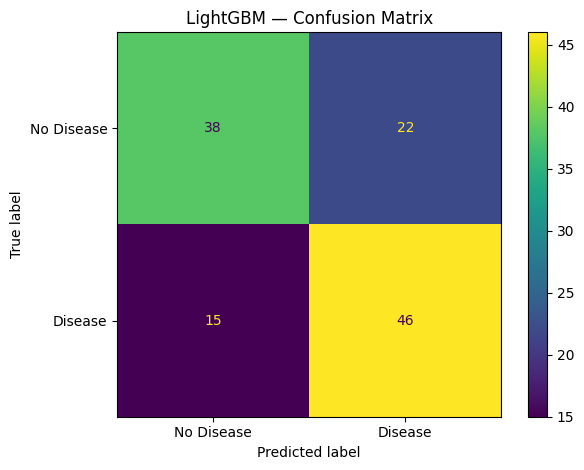

In [9]:
print("\n" + "=" * 70)
print("CONFUSION MATRICES")
print("=" * 70)

for name, pipe in best_models.items():
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    TN, FP, FN, TP = cm.ravel()

    print(f"\n{name}:")
    print(f"  TN={TN:3d} | FP={FP:3d} | FN={FN:3d} | TP={TP:3d}")
    print(f"  Recall (Sensitivity): {TP/(TP+FN):.4f}")
    print(f"  Specificity: {TN/(TN+FP):.4f}")

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Disease", "Disease"])
    disp.plot()
    plt.title(f"{name} — Confusion Matrix")
    plt.tight_layout()
    plt.show()

---
## 9. ROC Curves Comparison


ROC CURVES


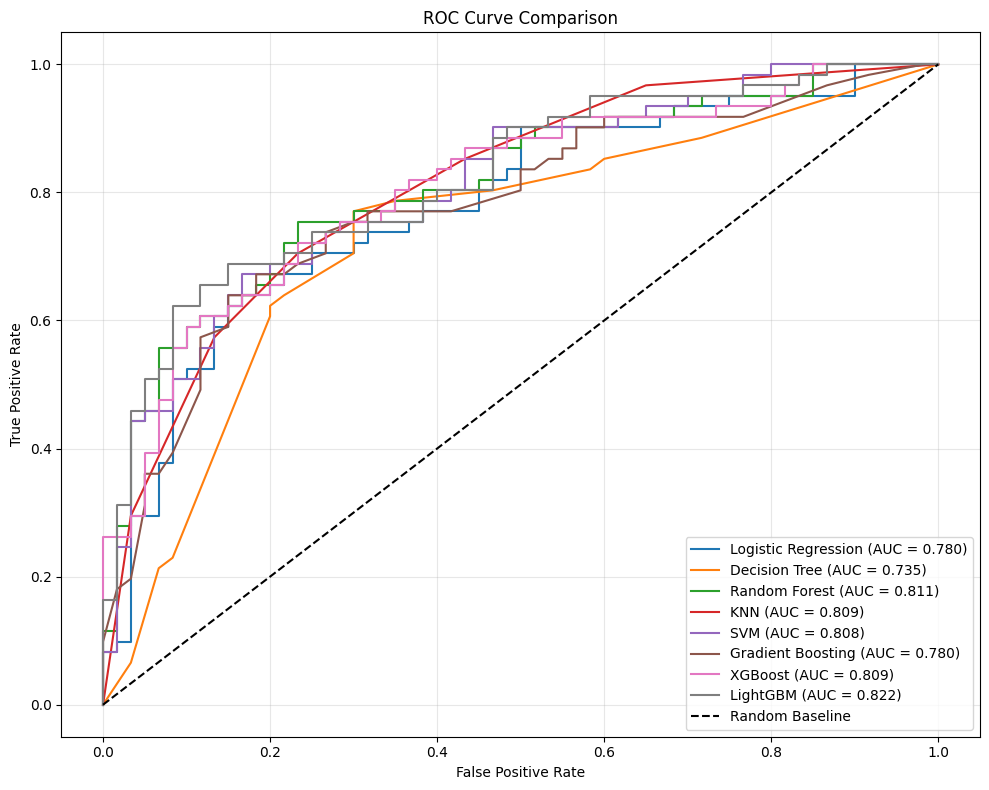


🏆 Best ROC-AUC Model: LightGBM


In [10]:
print("\n" + "=" * 70)
print("ROC CURVES")
print("=" * 70)

plt.figure(figsize=(10, 8))
for name, pipe in best_models.items():
    y_prob = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Baseline')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Find best AUC model
best_auc_model = max(best_models, key=lambda name: auc(
    *roc_curve(y_test, best_models[name].predict_proba(X_test)[:, 1])[:2]
))
print(f"\n🏆 Best ROC-AUC Model: {best_auc_model}")

---
## 10. Precision-Recall Curves


PRECISION-RECALL CURVES


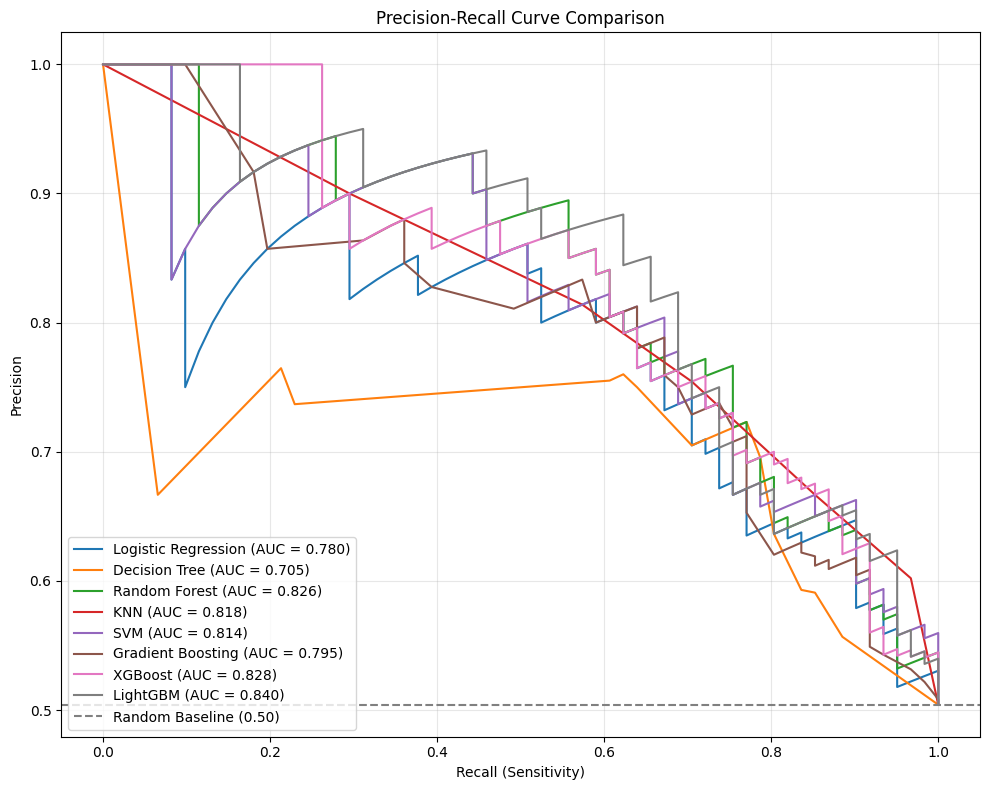

In [11]:
print("\n" + "=" * 70)
print("PRECISION-RECALL CURVES")
print("=" * 70)

plt.figure(figsize=(10, 8))
baseline = y_test.sum() / len(y_test)

for name, pipe in best_models.items():
    y_prob = pipe.predict_proba(X_test)[:, 1]
    prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(rec_curve, prec_curve)
    plt.plot(rec_curve, prec_curve, label=f"{name} (AUC = {pr_auc:.3f})")

plt.axhline(y=baseline, linestyle='--', color='grey', label=f"Random Baseline ({baseline:.2f})")
plt.xlabel("Recall (Sensitivity)")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## 11. Overfitting Check

In [12]:
print("\n" + "=" * 90)
print("OVERFITTING CHECK — Train Recall vs Test Recall")
print("=" * 90)
print(f"{'Model':<22}  {'Train Recall':>12}  {'Test Recall':>11}  {'Gap':>8}  {'Status':>16}")
print("-" * 78)

overfit_results = []
for name, pipe in best_models.items():
    train_rec = recall_score(y_train, pipe.predict(X_train))
    test_rec  = recall_score(y_test,  pipe.predict(X_test))
    gap       = train_rec - test_rec
    # Gap > 0.10 on Recall is a meaningful overfit signal for clinical models
    status    = "⚠️  OVERFIT"  if gap > 0.10 else ("✅ OK" if gap >= 0 else "⬇️  UNDERFIT")
    overfit_results.append({'Model': name, 'Train Recall': train_rec,
                            'Test Recall': test_rec, 'Gap': gap, 'Status': status})
    print(f"{name:<22}  {train_rec:>12.4f}  {test_rec:>11.4f}  {gap:>8.4f}  {status:>16}")

overfit_df = pd.DataFrame(overfit_results)



OVERFITTING CHECK — Train Recall vs Test Recall
Model                   Train Recall  Test Recall       Gap            Status
------------------------------------------------------------------------------
Logistic Regression           0.8140       0.7705    0.0436              ✅ OK
Decision Tree                 0.8264       0.7049    0.1215       ⚠️  OVERFIT
Random Forest                 0.8182       0.7705    0.0477              ✅ OK
KNN                           0.8512       0.7049    0.1463       ⚠️  OVERFIT
SVM                           0.8264       0.7705    0.0560              ✅ OK
Gradient Boosting             0.8347       0.7705    0.0642              ✅ OK
XGBoost                       0.8264       0.7869    0.0396              ✅ OK
LightGBM                      0.8554       0.7541    0.1013       ⚠️  OVERFIT


In [13]:
#fairness analysis


print("\n" + "=" * 90)
print("ADVANCED FAIRNESS ANALYSIS ACROSS ALL MODELS")
print("=" * 90)

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    tn, fp, fn, tp = cm.ravel()
    
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0  # TPR
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    
    return recall, fpr, precision, accuracy


fairness_results = []

for name, pipe in best_models.items():
    print(f"\n▶ Model: {name}")
    
    y_pred = pipe.predict(X_test)
    
    df_fair = X_test.copy()
    df_fair['y_true'] = y_test
    df_fair['y_pred'] = y_pred
    
    group_metrics = {}
    
    # ---- GROUP METRICS ----
    for sex_val in sorted(df_fair['sex'].unique()):
        mask = df_fair['sex'] == sex_val
        
        y_true_g = df_fair.loc[mask, 'y_true']
        y_pred_g = df_fair.loc[mask, 'y_pred']
        
        if len(y_true_g) == 0:
            continue
        
        recall, fpr, precision, accuracy = compute_metrics(y_true_g, y_pred_g)
        
        label = "Male" if sex_val == 1 else "Female"
        
        group_metrics[label] = {
            "recall": recall,
            "fpr": fpr,
            "precision": precision,
            "accuracy": accuracy
        }
        
        print(f"\n  {label}:")
        print(f"    Recall    : {recall:.4f}")
        print(f"    FPR       : {fpr:.4f}")
        print(f"    Precision : {precision:.4f}")
        print(f"    Accuracy  : {accuracy:.4f}")
    
    # ---- FAIRNESS GAPS ----
    if len(group_metrics) == 2:
        male = group_metrics["Male"]
        female = group_metrics["Female"]
        
        recall_gap = abs(male["recall"] - female["recall"])
        fpr_gap = abs(male["fpr"] - female["fpr"])
        precision_gap = abs(male["precision"] - female["precision"])
        
        print("\n  🔍 FAIRNESS GAPS:")
        print(f"    Recall Gap (Equal Opportunity): {recall_gap:.4f}")
        print(f"    FPR Gap (Equalized Odds)      : {fpr_gap:.4f}")
        print(f"    Precision Gap                 : {precision_gap:.4f}")
        
        # ---- STORE RESULTS ----
        fairness_results.append({
            "Model": name,
            "Recall Gap": recall_gap,
            "FPR Gap": fpr_gap,
            "Precision Gap": precision_gap,
            "Avg Gap": (recall_gap + fpr_gap + precision_gap) / 3
        })

# ===============================
# FINAL COMPARISON TABLE
# ===============================

fairness_df = pd.DataFrame(fairness_results)

print("\n" + "=" * 90)
print("📊 FAIRNESS COMPARISON ACROSS MODELS")
print("=" * 90)

fairness_df = fairness_df.sort_values(by="Avg Gap")

print(fairness_df.to_string(index=False))

# ===============================
# MOST FAIR MODEL
# ===============================

best_fair_model = fairness_df.iloc[0]

print("\n" + "=" * 90)
print("🏆 MOST FAIR MODEL")
print("=" * 90)

print(f"Model: {best_fair_model['Model']}")
print(f"Average Fairness Gap: {best_fair_model['Avg Gap']:.4f}")

# ===============================
# INTERPRETATION
# ===============================

print("\n" + "=" * 90)
print("⚖️ FINAL INTERPRETATION")
print("=" * 90)

for _, row in fairness_df.iterrows():
    if row["Avg Gap"] < 0.05:
        status = "✅ Fair"
    elif row["Avg Gap"] < 0.1:
        status = "⚠️ Moderate Bias"
    else:
        status = "🚨 High Bias"
    
    print(f"{row['Model']}: {status} (Avg Gap = {row['Avg Gap']:.4f})")


ADVANCED FAIRNESS ANALYSIS ACROSS ALL MODELS

▶ Model: Logistic Regression

  Female:
    Recall    : 0.7500
    FPR       : 0.2632
    Precision : 0.7826
    Accuracy  : 0.7442

  Male:
    Recall    : 0.7838
    FPR       : 0.4878
    Precision : 0.5918
    Accuracy  : 0.6410

  🔍 FAIRNESS GAPS:
    Recall Gap (Equal Opportunity): 0.0338
    FPR Gap (Equalized Odds)      : 0.2246
    Precision Gap                 : 0.1908

▶ Model: Decision Tree

  Female:
    Recall    : 0.7500
    FPR       : 0.0526
    Precision : 0.9474
    Accuracy  : 0.8372

  Male:
    Recall    : 0.6757
    FPR       : 0.4146
    Precision : 0.5952
    Accuracy  : 0.6282

  🔍 FAIRNESS GAPS:
    Recall Gap (Equal Opportunity): 0.0743
    FPR Gap (Equalized Odds)      : 0.3620
    Precision Gap                 : 0.3521

▶ Model: Random Forest

  Female:
    Recall    : 0.8750
    FPR       : 0.2632
    Precision : 0.8077
    Accuracy  : 0.8140

  Male:
    Recall    : 0.7027
    FPR       : 0.3902
    Precisio

---
## 12. Statistical Significance Testing (McNemar's Test)

McNemar's test is used to compare pairwise performance between models.

In [14]:
# Requires: pip install statsmodels
from statsmodels.stats.contingency_tables import mcnemar as mcnemar_test
from itertools import combinations

print("\n" + "=" * 80)
print("McNemar's TEST — Pairwise Model Comparison")
print("Continuity-corrected  |  Bonferroni-Holm correction for 28 pairs")
print("=" * 80)

predictions  = {name: best_models[name].predict(X_test) for name in best_models}
model_names  = list(best_models.keys())
pairs        = list(combinations(model_names, 2))

raw_results = []

for m1, m2 in pairs:
    p1, p2 = predictions[m1], predictions[m2]
    y_arr  = np.array(y_test)

    b = int(np.sum((p1 == y_arr) & (p2 != y_arr)))   # m1 right, m2 wrong
    c = int(np.sum((p1 != y_arr) & (p2 == y_arr)))   # m1 wrong, m2 right

    if b + c == 0:
        raw_results.append((m1, m2, None, b, c))
        continue

    # Contingency table [[a, b],[c, d]] where a=both right, d=both wrong
    a = int(np.sum((p1 == y_arr) & (p2 == y_arr)))
    d = int(np.sum((p1 != y_arr) & (p2 != y_arr)))
    table = [[a, b], [c, d]]

    result  = mcnemar_test(table, exact=False, correction=True)  # chi2 + continuity correction
    raw_results.append((m1, m2, result.pvalue, b, c))

# ── Bonferroni-Holm correction ────────────────────────────────────────────────
valid    = [(m1, m2, p, b, c) for m1, m2, p, b, c in raw_results if p is not None]
invalid  = [(m1, m2, p, b, c) for m1, m2, p, b, c in raw_results if p is None]

pvals    = [p for *_, p, _, _ in valid]
n_tests  = len(pvals)

# Holm-Bonferroni: sort ascending, compare p[i] to α/(n-i)
sorted_idx  = np.argsort(pvals)
corrected   = [False] * len(pvals)
reject_flag = True
for rank, idx in enumerate(sorted_idx):
    threshold = 0.05 / (n_tests - rank)
    if reject_flag and pvals[idx] <= threshold:
        corrected[idx] = True
    else:
        reject_flag = False   # once we fail to reject, all subsequent are kept null

print(f"\n{'Model A':<22} {'Model B':<22} {'b':>4} {'c':>4} {'p-value':>10} {'Holm α':>10} {'Sig?':>6}")
print("-" * 80)

for (m1, m2, p, b, c), sig in zip(valid, corrected):
    rank    = sorted_idx.tolist().index(valid.index((m1, m2, p, b, c)))
    holm_a  = 0.05 / (n_tests - rank)
    flag    = "✅ Yes" if sig else "❌ No"
    print(f"{m1:<22} {m2:<22} {b:>4} {c:>4} {p:>10.4f} {holm_a:>10.4f} {flag:>6}")

for m1, m2, _, b, c in invalid:
    print(f"{m1:<22} {m2:<22} {b:>4} {c:>4} {'N/A — identical predictions':>28}")

sig_count = sum(corrected)
print(f"\n{sig_count} of {n_tests} pairs significantly different after Holm-Bonferroni correction (α=0.05)")
print("Note: On ~60 test samples, most pairs will NOT reach significance — this is expected.")



McNemar's TEST — Pairwise Model Comparison
Continuity-corrected  |  Bonferroni-Holm correction for 28 pairs

Model A                Model B                   b    c    p-value     Holm α   Sig?
--------------------------------------------------------------------------------
Logistic Regression    Decision Tree            12   15     0.7003     0.0036   ❌ No
Logistic Regression    Random Forest             3    7     0.3428     0.0021   ❌ No
Logistic Regression    KNN                      10   17     0.2482     0.0019   ❌ No
Logistic Regression    SVM                       5    7     0.7728     0.0050   ❌ No
Logistic Regression    Gradient Boosting         6   12     0.2386     0.0019   ❌ No
Logistic Regression    XGBoost                   5   10     0.3017     0.0020   ❌ No
Logistic Regression    LightGBM                  6    8     0.7893     0.0056   ❌ No
Decision Tree          Random Forest             9   10     1.0000     0.0083   ❌ No
Decision Tree          KNN                  

---
## 13. Feature Importance (Random Forest MDI)


ROBUST FEATURE IMPORTANCE — MDI + PERMUTATION

[INFO] Checking MDI support for: XGBoost
[INFO] MDI supported ✔


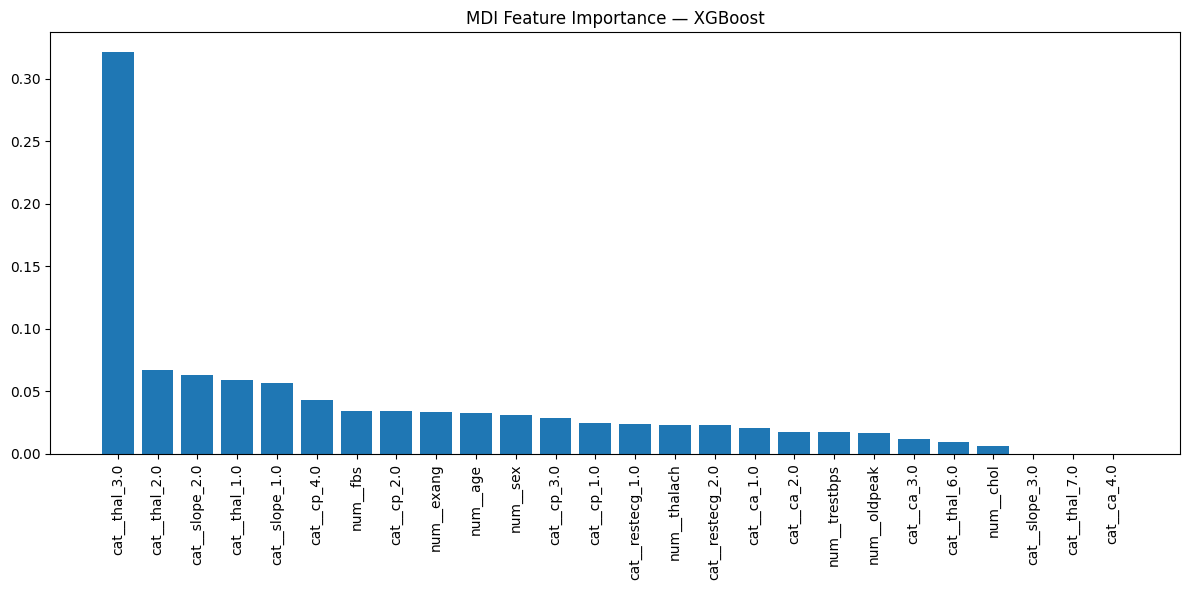


[INFO] Computing permutation importance (XGBoost)...

Top Features (Permutation Importance):
 Feature  Importance_Mean  Importance_Std
    thal         0.169399        0.042398
 thalach         0.015301        0.008395
    chol         0.011475        0.007512
 restecg         0.010929        0.007728
      cp         0.010929        0.021304
   slope         0.009290        0.021865
      ca         0.006011        0.007900
   exang         0.006011        0.007900
trestbps         0.004372        0.007249
     fbs         0.002732        0.006109
 oldpeak         0.001639        0.014260
     age        -0.002732        0.015310
     sex        -0.007650        0.008178


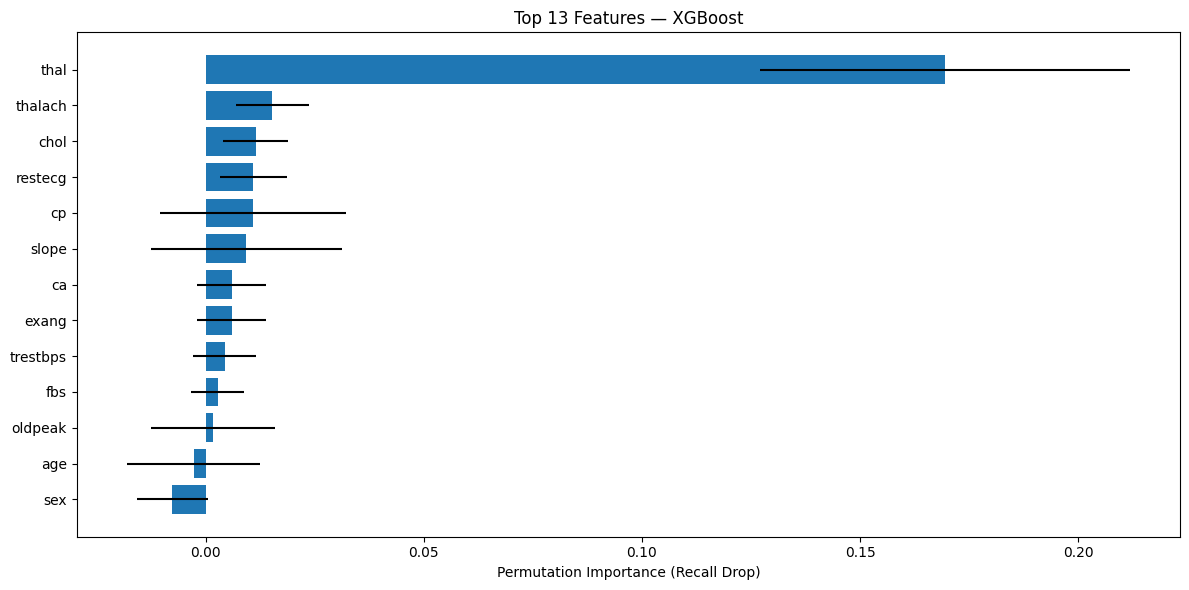


[INFO] Results saved as feature_importance_XGBoost.csv


In [15]:
print("\n" + "=" * 70)
print("ROBUST FEATURE IMPORTANCE — MDI + PERMUTATION")
print("=" * 70)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

# ─────────────────────────────────────────────────────────────
# 🔒 SAFE EXTRACTION OF MODEL + PREPROCESSOR
# ─────────────────────────────────────────────────────────────
model_pipeline = best_models[BEST_MODEL_NAME]

try:
    clf = model_pipeline.named_steps['classifier']
    preprocessor = model_pipeline.named_steps['preprocessor']
except Exception as e:
    raise ValueError("Pipeline must contain 'classifier' and 'preprocessor' steps")

# ─────────────────────────────────────────────────────────────
# 🧠 FEATURE NAMES (SAFE HANDLING)
# ─────────────────────────────────────────────────────────────
def get_feature_names_safe(preprocessor, X):
    try:
        return preprocessor.get_feature_names_out()
    except:
        return np.array(X.columns)

feat_names_transformed = get_feature_names_safe(preprocessor, X_test)
feat_names_original    = np.array(X_test.columns)

# ─────────────────────────────────────────────────────────────
# 🌳 MDI FEATURE IMPORTANCE (TREE MODELS ONLY)
# ─────────────────────────────────────────────────────────────
print(f"\n[INFO] Checking MDI support for: {BEST_MODEL_NAME}")

if hasattr(clf, "feature_importances_"):
    print("[INFO] MDI supported ✔")

    importances = clf.feature_importances_

    # Safety check
    if len(importances) != len(feat_names_transformed):
        print("[WARNING] Length mismatch in MDI — skipping plot")
    else:
        indices = np.argsort(importances)[::-1]

        plt.figure(figsize=(12, 6))
        plt.title(f"MDI Feature Importance — {BEST_MODEL_NAME}")
        plt.bar(range(len(importances)), importances[indices])
        plt.xticks(range(len(importances)),
                   feat_names_transformed[indices],
                   rotation=90)
        plt.tight_layout()
        plt.show()

else:
    print("[INFO] MDI not supported — skipping")

# ─────────────────────────────────────────────────────────────
# 🔁 PERMUTATION IMPORTANCE (FAIL-SAFE)
# ─────────────────────────────────────────────────────────────
print(f"\n[INFO] Computing permutation importance ({BEST_MODEL_NAME})...")

try:
    perm = permutation_importance(
        model_pipeline,   # full pipeline (SAFE)
        X_test,
        y_test,
        n_repeats=30,
        random_state=RANDOM_STATE,
        scoring='recall',
        n_jobs=-1
    )
except Exception as e:
    raise RuntimeError(f"Permutation importance failed: {e}")

# ─────────────────────────────────────────────────────────────
# 🛡️ LENGTH ALIGNMENT (CRITICAL FIX)
# ─────────────────────────────────────────────────────────────
if len(perm.importances_mean) == len(feat_names_original):
    feat_names_perm = feat_names_original
elif len(perm.importances_mean) == len(feat_names_transformed):
    feat_names_perm = feat_names_transformed
else:
    raise ValueError(
        f"Feature mismatch:\n"
        f"Permutation: {len(perm.importances_mean)}\n"
        f"Original: {len(feat_names_original)}\n"
        f"Transformed: {len(feat_names_transformed)}"
    )

# ─────────────────────────────────────────────────────────────
# 📊 CREATE CLEAN DATAFRAME
# ─────────────────────────────────────────────────────────────
perm_df = pd.DataFrame({
    "Feature": feat_names_perm,
    "Importance_Mean": perm.importances_mean,
    "Importance_Std": perm.importances_std
})

perm_df = (
    perm_df
    .sort_values("Importance_Mean", ascending=False)
    .reset_index(drop=True)
)

print("\nTop Features (Permutation Importance):")
print(perm_df.head(20).to_string(index=False))

# ─────────────────────────────────────────────────────────────
# 📉 VISUALIZATION (TOP 15)
# ─────────────────────────────────────────────────────────────
top_n = min(15, len(perm_df))

plt.figure(figsize=(12, 6))
plt.barh(
    perm_df["Feature"][:top_n][::-1],
    perm_df["Importance_Mean"][:top_n][::-1],
    xerr=perm_df["Importance_Std"][:top_n][::-1]
)
plt.xlabel("Permutation Importance (Recall Drop)")
plt.title(f"Top {top_n} Features — {BEST_MODEL_NAME}")
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────
# 💾 OPTIONAL: SAVE RESULTS
# ─────────────────────────────────────────────────────────────
try:
    perm_df.to_csv(f"feature_importance_{BEST_MODEL_NAME}.csv", index=False)
    print(f"\n[INFO] Results saved as feature_importance_{BEST_MODEL_NAME}.csv")
except:
    print("[WARNING] Could not save file")

---
## 14. SHAP Analysis — Applied to the Best Model

SHAP is applied to whichever model scored highest on Recall (the clinical
priority metric) — **not hard-coded to Random Forest**.

- Tree-based models (RF, XGBoost, LightGBM, GBM, DT) use the fast exact
  `TreeExplainer`.
- All other models (SVM, LR, KNN) fall back to the model-agnostic
  `KernelExplainer` with a 50-sample background set.

This ensures the XAI section of the paper honestly explains the model
being recommended for deployment.


In [16]:
print("\n" + "=" * 70)
print("SHAP ANALYSIS — Best Model by Recall")
print("=" * 70)

# ── 1. Use the single authoritative best model (set in test evaluation cell) ──
# BEST_MODEL_NAME is defined once in the test evaluation cell (sorted by Recall)
best_pipe = best_models[BEST_MODEL_NAME]
best_clf  = best_pipe.named_steps['classifier']

print(f"Best model (highest Recall): {BEST_MODEL_NAME}")
print(f"Classifier type            : {type(best_clf).__name__}")

# ── 2. Transform test data once ──────────────────────────────────────────────
preprocessor_fitted = best_pipe.named_steps['preprocessor']
X_test_transformed  = preprocessor_fitted.transform(X_test)
feature_names       = preprocessor_fitted.get_feature_names_out()

# ── 3. Choose explainer based on model type ──────────────────────────────────
TREE_TYPES = (
    RandomForestClassifier,
    GradientBoostingClassifier,
    DecisionTreeClassifier,
    XGBClassifier,
    LGBMClassifier,
)

if isinstance(best_clf, TREE_TYPES):
    print("Using TreeExplainer (fast, exact for tree models)")
    explainer  = shap.TreeExplainer(best_clf)
    shap_vals  = explainer.shap_values(X_test_transformed)
else:
    print("Using KernelExplainer (model-agnostic fallback)")
    background = shap.sample(X_test_transformed, 50,
                             random_state=RANDOM_STATE)
    explainer  = shap.KernelExplainer(best_clf.predict_proba, background)
    shap_vals  = explainer.shap_values(X_test_transformed)

# ── 4. Normalise output shape across SHAP versions ───────────────────────────
# shap_values can be:
#   list of arrays  → shap_vals[1]          (older TreeExplainer / multi-class)
#   3-D array       → shap_vals[:, :, 1]    (newer TreeExplainer)
#   2-D array       → shap_vals             (KernelExplainer binary class-1)
if isinstance(shap_vals, list):
    shap_class1 = shap_vals[1]
elif hasattr(shap_vals, 'shape') and len(shap_vals.shape) == 3:
    shap_class1 = shap_vals[:, :, 1]
else:
    shap_class1 = shap_vals

print(f"SHAP values shape : {shap_class1.shape}")
print(f"Feature count     : {len(feature_names)}")



SHAP ANALYSIS — Best Model by Recall
Best model (highest Recall): XGBoost
Classifier type            : XGBClassifier
Using TreeExplainer (fast, exact for tree models)
SHAP values shape : (121, 26)
Feature count     : 26



SHAP Feature Importance — XGBoost
         Feature  SHAP Importance
   cat__thal_3.0         0.614878
  cat__slope_2.0         0.157205
     cat__cp_4.0         0.116819
  cat__slope_1.0         0.104955
        num__age         0.055798
   cat__thal_1.0         0.025480
cat__restecg_1.0         0.021800
   cat__thal_2.0         0.020840
        num__sex         0.015693
     cat__cp_1.0         0.015460
    num__oldpeak         0.013463
     cat__cp_3.0         0.010954
      num__exang         0.009255
     cat__cp_2.0         0.008369
   num__trestbps         0.007605
    num__thalach         0.005655
     cat__ca_1.0         0.003363
       num__chol         0.002920
        num__fbs         0.002823
     cat__ca_3.0         0.001388
cat__restecg_2.0         0.000868
   cat__thal_6.0         0.000828
     cat__ca_2.0         0.000334
  cat__slope_3.0         0.000000
     cat__ca_4.0         0.000000
   cat__thal_7.0         0.000000


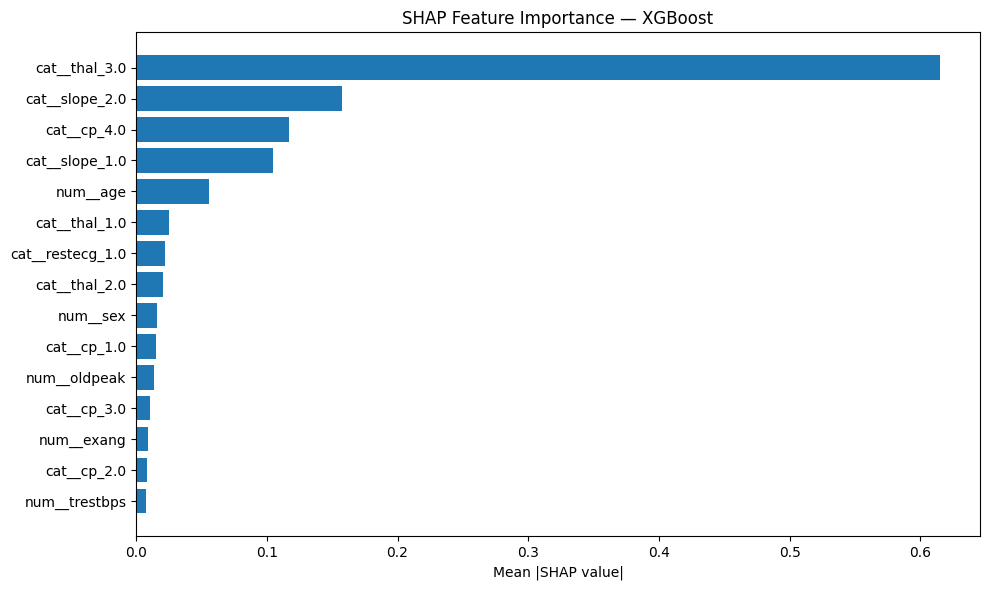

In [17]:
# ── SHAP mean absolute importance table ─────────────────────────────────────
feature_importance = np.mean(np.abs(shap_class1), axis=0)
shap_df = (
    pd.DataFrame({'Feature': feature_names, 'SHAP Importance': feature_importance})
    .sort_values('SHAP Importance', ascending=False)
    .reset_index(drop=True)
)

print(f"\nSHAP Feature Importance — {BEST_MODEL_NAME}")
print(shap_df.to_string(index=False))

# ── Bar chart ────────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 6))
plt.barh(shap_df['Feature'][:15][::-1], shap_df['SHAP Importance'][:15][::-1])
plt.xlabel('Mean |SHAP value|')
plt.title(f'SHAP Feature Importance — {BEST_MODEL_NAME}')
plt.tight_layout()
plt.show()


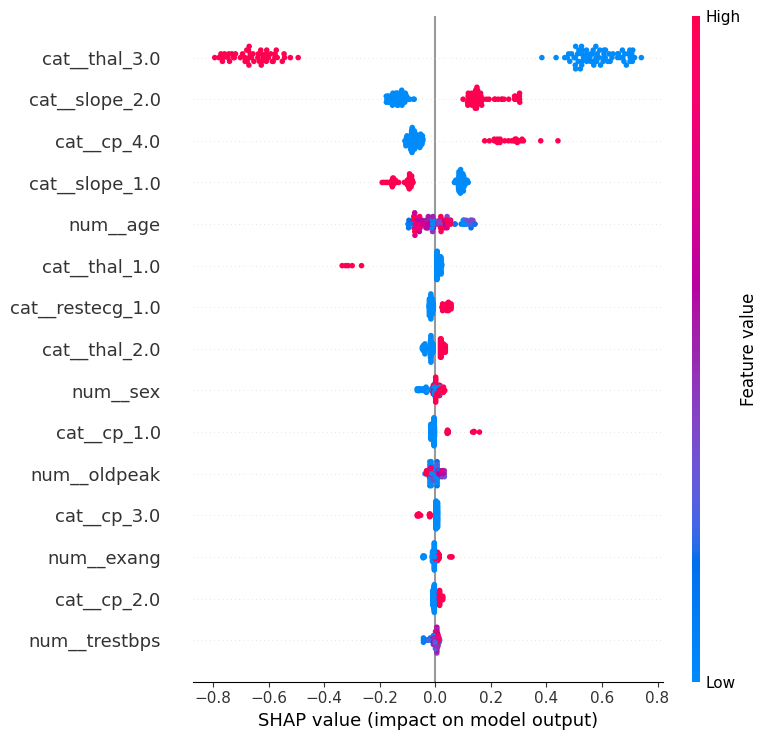

In [18]:
# ── Beeswarm (summary) plot ───────────────────────────────────────────────────
shap.summary_plot(
    shap_class1,
    X_test_transformed,
    feature_names=feature_names,
    plot_type='dot',
    show=True,
    max_display=15,
    title=f'SHAP Beeswarm — {BEST_MODEL_NAME}'
)


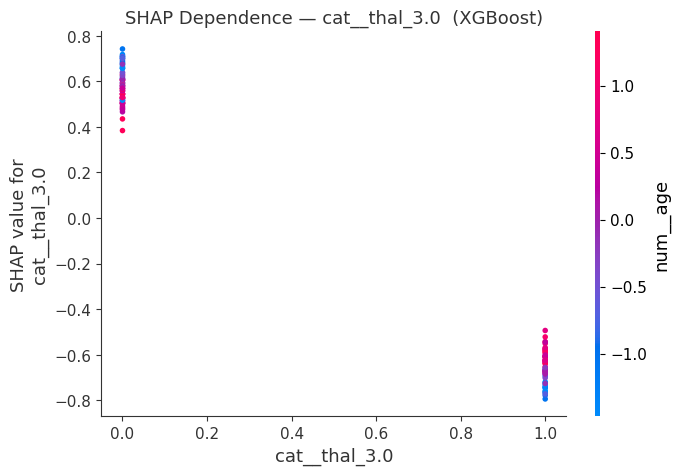

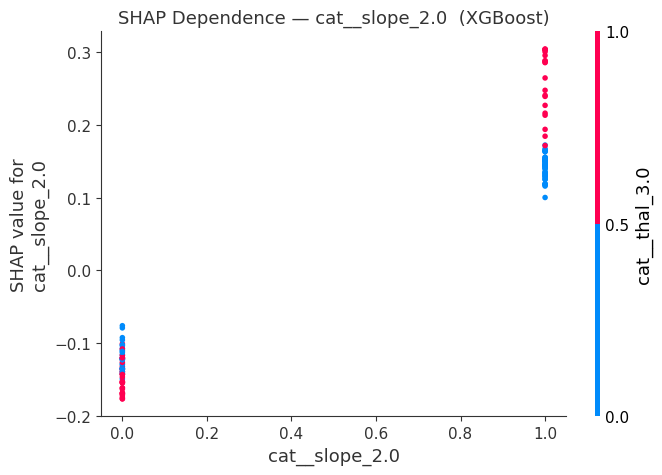

In [19]:
# ── Dependence plots for top 2 features ─────────────────────────────────────
# These show how the effect of a feature changes across its value range
# and reveal interaction effects — expected in clinical ML papers.
top2 = shap_df['Feature'].iloc[:2].tolist()

for feat in top2:
    feat_idx = list(feature_names).index(feat)
    shap.dependence_plot(
        feat_idx,
        shap_class1,
        X_test_transformed,
        feature_names=feature_names,
        show=True,
        title=f'SHAP Dependence — {feat}  ({BEST_MODEL_NAME})'
    )



True Positive  — correctly flagged disease  (sample index 0)


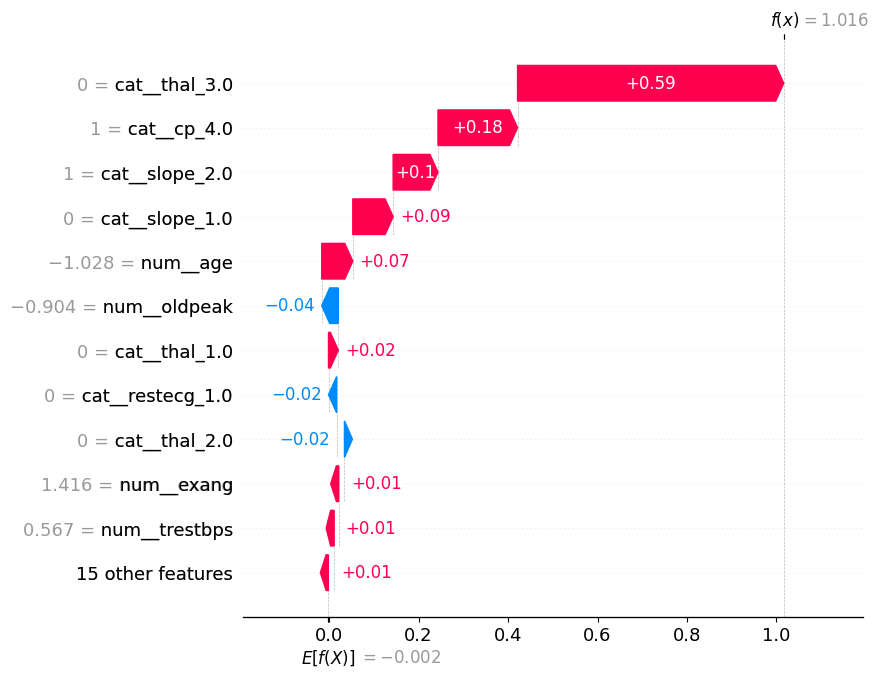


False Positive — healthy patient over-flagged  (sample index 17)


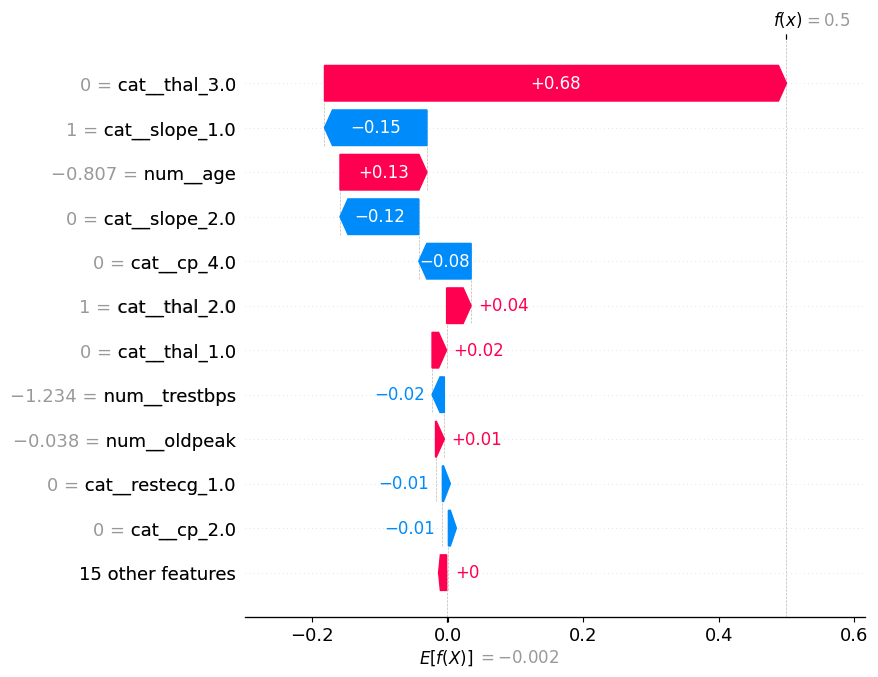


False Negative — missed disease case  (sample index 7)


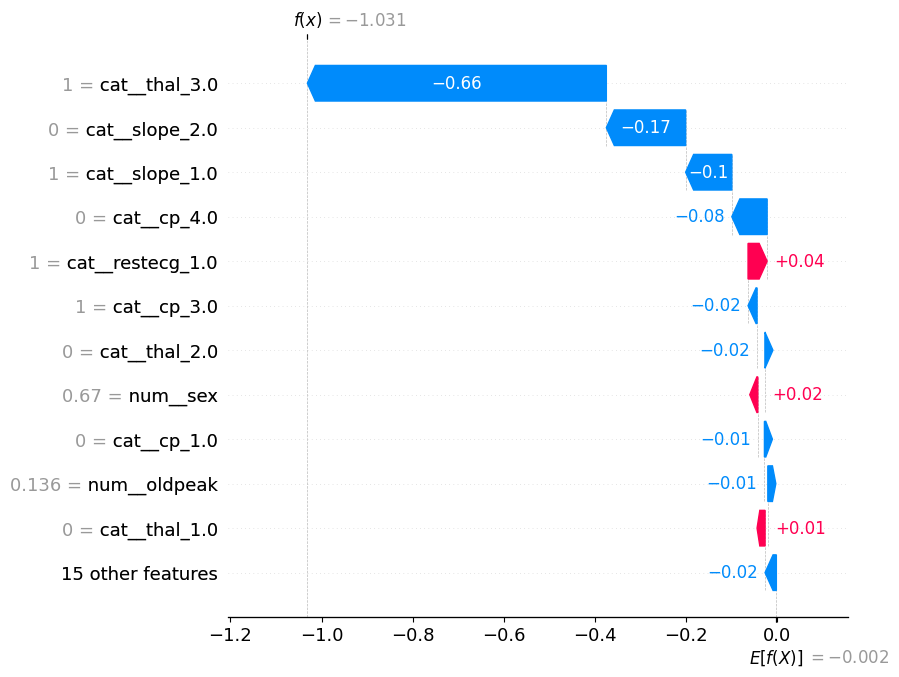

In [20]:
# ── Waterfall plots for individual predictions (TP, FP, FN) ─────────────────
# Essential for clinical utility demonstration in the paper.
y_pred_best = best_pipe.predict(X_test)
y_prob_best = best_pipe.predict_proba(X_test)[:, 1]

idx_tp = np.where((y_pred_best == 1) & (y_test.values == 1))[0]
idx_fp = np.where((y_pred_best == 1) & (y_test.values == 0))[0]
idx_fn = np.where((y_pred_best == 0) & (y_test.values == 1))[0]

cases = []
if len(idx_tp): cases.append((idx_tp[0],  'True Positive  — correctly flagged disease'))
if len(idx_fp): cases.append((idx_fp[0],  'False Positive — healthy patient over-flagged'))
if len(idx_fn): cases.append((idx_fn[0],  'False Negative — missed disease case'))

# Build a shap.Explanation object for waterfall compatibility
exp = shap.Explanation(
    values          = shap_class1,
    base_values     = (explainer.expected_value[1]                    # RF/GBM: list[class0, class1]
                        if isinstance(explainer.expected_value, (list, np.ndarray)) and len(np.atleast_1d(explainer.expected_value)) > 1
                        else float(np.atleast_1d(explainer.expected_value)[0])),  # KernelExplainer: scalar
    data            = X_test_transformed,
    feature_names   = list(feature_names)
)

for sample_idx, label in cases:
    print(f"\n{label}  (sample index {sample_idx})")
    shap.plots.waterfall(exp[sample_idx], max_display=12, show=True)


---
## 15. Clinical Threshold Tuning

Optimize classification threshold to achieve **Recall ≥ 0.90** for clinical deployment.
This is critical in medical diagnosis where missing a positive case (False Negative) is costly.

In [21]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_recall_curve, recall_score, precision_score, f1_score

print("\n" + "=" * 70)
print("LEAKAGE-FREE CLINICAL THRESHOLD TUNING (CV-based)")
print("=" * 70)

threshold_results = []

# Use CV on TRAIN set to estimate stable threshold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, pipe in best_models.items():
    print(f"\n▶ {name}")

    thresholds_cv = []

    # ── 1. Cross-validated threshold estimation ───────────────────────
    for train_idx, val_idx in cv.split(X_train, y_train):

        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = clone(pipe)
        model.fit(X_tr, y_tr)

        y_val_prob = model.predict_proba(X_val)[:, 1]

        precisions, recalls, thresholds = precision_recall_curve(y_val, y_val_prob)

        aligned_recalls = recalls[:-1]
        aligned_precisions = precisions[:-1]

        idx = np.where(aligned_recalls >= 0.90)[0]

        if len(idx) == 0:
            continue

        best_idx = idx[np.argmax(aligned_precisions[idx])]
        thresholds_cv.append(thresholds[best_idx])

    # ── 2. Aggregate threshold (robust) ───────────────────────────────
    if len(thresholds_cv) == 0:
        print("  ❌ Cannot reach Recall ≥ 0.90 in CV")
        continue

    opt_thresh = np.median(thresholds_cv)  # robust aggregation

    # ── 3. FINAL evaluation on TEST (unseen) ─────────────────────────
    y_test_prob = pipe.predict_proba(X_test)[:, 1]
    y_test_pred = (y_test_prob >= opt_thresh).astype(int)

    rec_tuned = recall_score(y_test, y_test_pred)
    prec_tuned = precision_score(y_test, y_test_pred)
    f1_tuned = f1_score(y_test, y_test_pred)

    print(f"  Threshold (CV median): {opt_thresh:.3f}")
    print(f"  Recall: {rec_tuned:.4f} | Precision: {prec_tuned:.4f} | F1: {f1_tuned:.4f}")

    threshold_results.append([name, opt_thresh, rec_tuned, prec_tuned, f1_tuned])


# ── Summary table ───────────────────────────────────────────────────────────
thresh_df = pd.DataFrame(
    threshold_results,
    columns=["Model", "Threshold", "Recall", "Precision", "F1"]
).sort_values(by="F1", ascending=False).reset_index(drop=True)

print("\n" + "-" * 70)
print("LEAKAGE-FREE THRESHOLD SUMMARY:")
print(thresh_df.to_string(index=False))
print(f"  Threshold std: {np.std(thresholds_cv):.3f}")


LEAKAGE-FREE CLINICAL THRESHOLD TUNING (CV-based)

▶ Logistic Regression
  Threshold (CV median): 0.458
  Recall: 0.9016 | Precision: 0.6471 | F1: 0.7534

▶ Decision Tree
  Threshold (CV median): 0.060
  Recall: 0.8525 | Precision: 0.5909 | F1: 0.6980

▶ Random Forest
  Threshold (CV median): 0.419
  Recall: 0.8689 | Precision: 0.6386 | F1: 0.7361

▶ KNN
  Threshold (CV median): 0.200
  Recall: 0.9672 | Precision: 0.6020 | F1: 0.7421

▶ SVM
  Threshold (CV median): 0.297
  Recall: 0.9016 | Precision: 0.6250 | F1: 0.7383

▶ Gradient Boosting
  Threshold (CV median): 0.367
  Recall: 0.9180 | Precision: 0.5895 | F1: 0.7179

▶ XGBoost
  Threshold (CV median): 0.367
  Recall: 0.8852 | Precision: 0.6207 | F1: 0.7297

▶ LightGBM
  Threshold (CV median): 0.307
  Recall: 0.9016 | Precision: 0.6395 | F1: 0.7483

----------------------------------------------------------------------
LEAKAGE-FREE THRESHOLD SUMMARY:
              Model  Threshold   Recall  Precision       F1
Logistic Regression   

---
## 16. Final Summary and Recommendations